<a href="https://colab.research.google.com/github/raulmabcn/DataAnalyst/blob/main/Specialization/PythonVisualData/S1101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from dotenv import load_dotenv
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# Nivell 1
Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [2]:
load_dotenv()
MYSQL_PASSWORD = os.getenv( 'MYSQL_PASSWORD' )

## 1.
Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [3]:
def connect_to_Mysql_database( config ):

  try:
    cns = mysql.connector.connect( **config )
  except mysql.connector.Error as err:
    if err.errno == mysql.connector.errorcode.ER_ACCESS_DENIED_ERROR:
      print( "Error de autentificación" )
    elif err.errno == mysql.connector.errorcode.ER_BAD_DB_ERROR:
      print( "La base de datos no existe" )
    raise
    
  return cns

In [4]:
def get_tables_from_database( connect ):

    cursor = connect.cursor()
    try:
        query = "SHOW TABLES"
        cursor.execute( query )

        tables = [table[0] for table in cursor.fetchall()]
        
    finally:
        cursor.close() 

    return tables

In [ ]:
def get_data_from_database( connect, tables, chunk_size=50000 ):

    # 7 - TimeStamp | 10 - Date | 12 - DateTime
    date_codes = (7, 10, 12)
    df_list = {}

    cursor = connect.cursor()

    try:
        for table in tables:

            query = f'SELECT * FROM {table}'
            cursor.execute( query )
            
            # cursor.description - [( [0]column_name, [1]type_code, [2]display_size, [3]internal_size, [4]precision, [5]sclase, [6]null_ok ),(...),...]
            description = cursor.description
            full_data   = []
            data_chunk  = cursor.fetchmany( chunk_size )
            
            while data_chunk:
                full_data.extend( data_chunk )
                data_chunk = cursor.fetchmany( chunk_size )

            df_list[table] = pd.DataFrame( data=full_data, columns=[column[0] for column in description ] )
            
            for column in [column[0] for column in description if column[1] in date_codes]:
                df_list[table][column] = pd.to_datetime( df_list[table][column], errors='coerce' )
    
    finally:
        cursor.close()

    return df_list

In [6]:
def prepare_df_data( df ):
    df['transaction']['amount'] = pd.to_numeric( df['transaction']['amount'], errors='coerce' )
    df['product']['price']      = pd.to_numeric( df['product']['price'], errors='coerce' )
    df['product']['weight']     = pd.to_numeric( df['product']['weight'], errors='coerce' )

    today = date.today()
    
    df['user']['age'] = today.year - df['user']['birth_date'].dt.year - (( df['user']['birth_date'].dt.month > today.month ) | \
                (( df['user']['birth_date'].dt.month == today.month ) & ( df['user']['birth_date'].dt.day > today.day ))).astype( int )

    return df

In [7]:
config = {
    'user':     'root',
    'password':  MYSQL_PASSWORD,
    'host':     '127.0.0.1',
    'database': 'sprint4'
}

try:
    cns         = connect_to_Mysql_database( config )
    tables_db   = get_tables_from_database( cns )
    df          = get_data_from_database( cns, tables_db )
    df          = prepare_df_data( df )


except Exception as e:
    print( f"Algo paso: {e}" )
finally:
    if cns and cns.is_connected():
        cns.close()

## 2.
Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.


>   Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar:

    2.1 Una variable numèrica.
    2.2 Dues variables numèriques.
    2.3 Una variable categòrica.
    2.4 Una variable categòrica i una numèrica.
    2.5 Dues variables categòriques.
    2.6 Tres variables combinades.
    2.7 Crea un Pairplot.




In [8]:
#Estableixo l’estil per a totes les visualitzacions.
plt.style.use( "seaborn-v0_8-paper" )

#### 2.1 Una variable numèrica

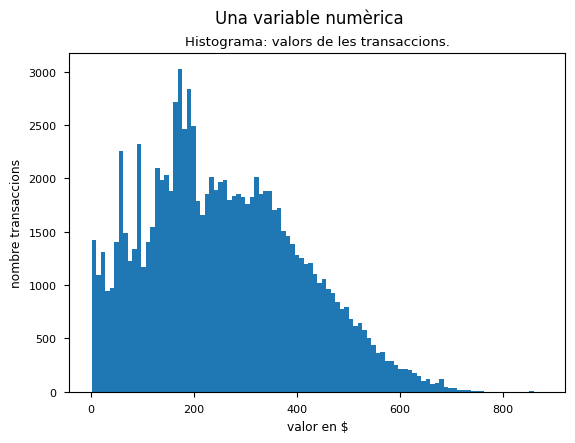

In [9]:
plt.suptitle( "Una variable numèrica" )
plt.title( "Histograma: valors de les transaccions.")

plt.hist( df['transaction']['amount'], bins=100 )

plt.ylabel( "nombre transaccions" ) 
plt.xlabel( "valor en $" )
plt.show()
plt.close()

Les transaccions se situen normalment entre els 2 i els 400 \$, amb una concentració més elevada entre els 150 \$ i els 250 \$. A partir dels 400 \$ i fins als 800 \$, s’observa clarament una tendència a la baixa.

#### 2.2 Dues variables numèriques.

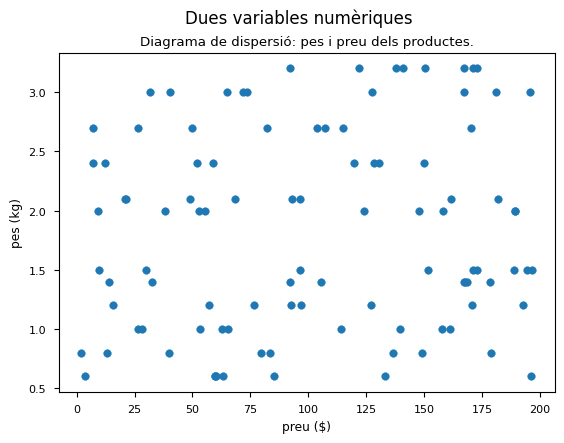

In [10]:
plt.suptitle( "Dues variables numèriques" )
plt.title( "Diagrama de dispersió: pes i preu dels productes." )

plt.scatter( df['product']['price'], df['product']['weight'] )

plt.xlabel( "preu ($)" )
plt.ylabel( "pes (kg)" )
plt.show()
plt.close()

No s’observa cap correlació clara entre les dues variables. Tant els productes barats com els cars poden ser lleugers o pesants.

##### 2.3 Una variable categòrica.

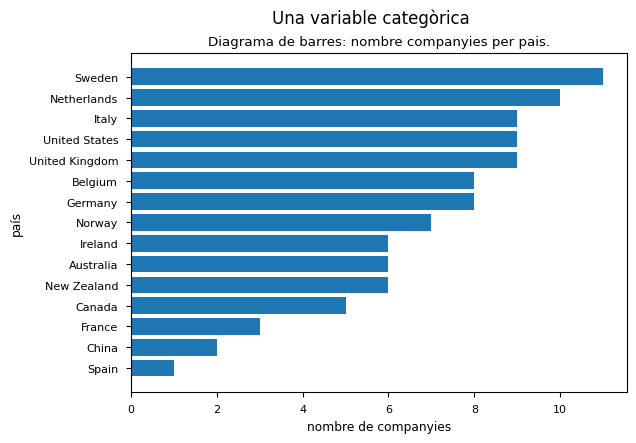

In [11]:
plt.suptitle( "Una variable categòrica" )
plt.title( "Diagrama de barres: nombre companyies per pais.")

countries = df['company']['country'].value_counts().sort_values( ascending=True )
plt.barh( y=countries.index, width=countries.values )

plt.ylabel( "país" )
plt.xlabel( "nombre de companyies" )
plt.show()
plt.close()


Suècia, amb 13, és el país amb més companyies, i Espanya, amb 1, el que en té menys.

#### 2.4 Una variable categòrica i una numèrica.

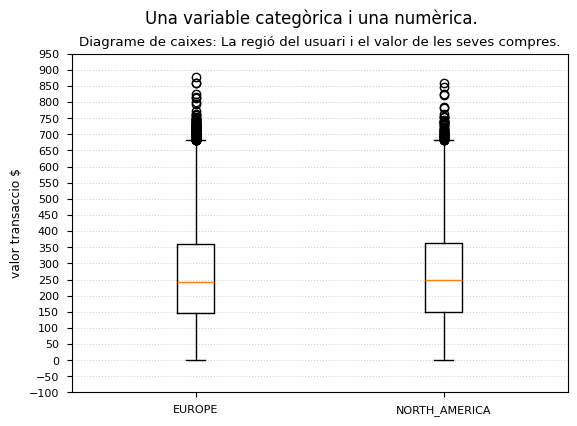

In [12]:
df_utar = pd.merge( df['user'][['id','region']], df['transaction'][['user_id','amount']], left_on='id', right_on='user_id', how='inner' )

regions = []
amounts = []

for region, group in df_utar.groupby( "region" ):
    regions.append( region )            
    amounts.append( group['amount'] )

plt.suptitle( "Una variable categòrica i una numèrica." )
plt.title( "Diagrame de caixes: La regió del usuari i el valor de les seves compres.")

plt.boxplot( amounts, tick_labels=regions )

plt.ylabel( "valor transaccio $" )
plt.grid( visible=True, axis='y', color='lightgrey', linestyle=':' )
plt.yticks( range(-100, 1000, 50) ) 
plt.show()
plt.close()


Es pot observar que el valor de les transaccions en ambdues regions és gairebé idèntic; a la regió de Nord-amèrica és lleugerament superior. Si bé a la regió europea hi ha puntualment transaccions amb un valor superior (outliers).

#### 2.5 Dues variables categòriques.

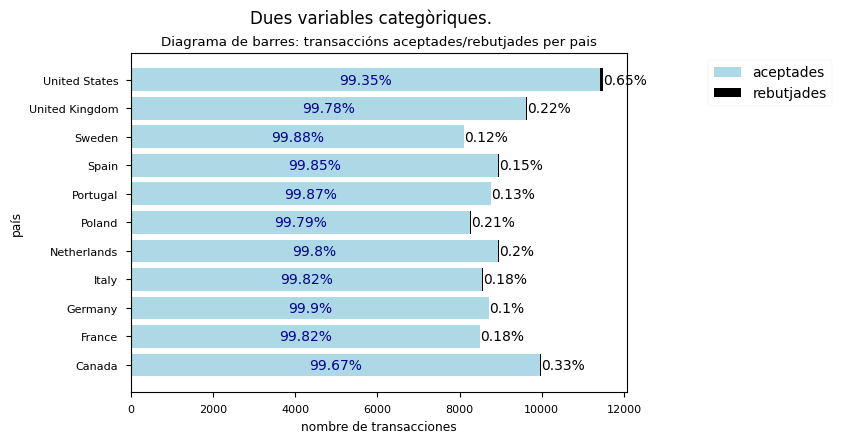

In [ ]:
df_cst = pd.merge( df['transaction'][['id','user_id','declined']], df['user'][['id','country']], left_on='user_id', right_on='id', how='inner'
                  ).pivot_table( index='country', columns='declined', values='id_x', aggfunc='count', fill_value=0 )

plt.suptitle( "Dues variables categòriques." )
plt.title( "Diagrama de barres: transaccións aceptades/rebutjades per pais" )


df_cst['%'] = round( ( df_cst[1] / ( df_cst[0] + df_cst[1] ) )*100, 2 )

barh1 = plt.barh( df_cst.index, df_cst[0], color='lightblue', label='aceptades' )
barh2 = plt.barh( df_cst.index, df_cst[1], left=df_cst[0],color='black', label='rebutjades' )



per_label1, per_label2 = zip( *[ (f"{100-per}%", f"{per}%") for per in df_cst['%'] ] )

ax = plt.gca()
ax.bar_label(
    barh2,
    labels=per_label2,
    label_type='edge',
    color='black',
    padding=0
)

ax.bar_label(
    barh1,
    labels=per_label1,
    label_type='center',
    color='darkBlue',
    padding=0
)

plt.legend( loc='best', bbox_to_anchor=(1.15, 1.0), frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10 )

plt.ylabel( "país" )
plt.xlabel( "nombre de transacciones" )
plt.show()
plt.close()


El nombre de transaccions rebutjades és mínim a tots els països. Es pot apreciar que Estats Units en té més, però també té un volum de transaccions més gran que la resta. En relació amb això, es pot veure que Polònia, tot i tenir un volum de transaccions menor, també presenta una certa presència de transaccions rebutjades.

#### 2.6 Tres variables combinades.

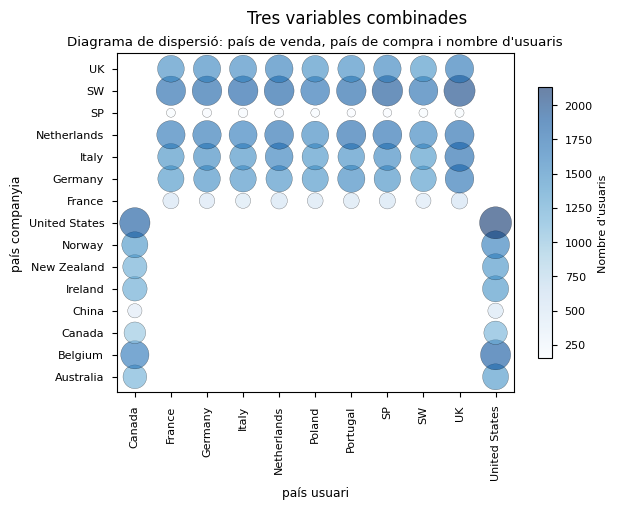

In [36]:
df_pctus    = pd.merge( df['company'][['id','country']], df['transaction'][['company_id','user_id']], left_on='id', right_on='company_id', how='inner' 
            ).rename( columns={'country' : 'company_country'}
            ).merge( df['user'][['id','country']], left_on='user_id', right_on='id', how='inner'
            ).rename( columns={'country' : 'user_country'}
            ).groupby( ['user_country', 'company_country'] ).size().reset_index( name='num_users' )

plt.suptitle( "Tres variables combinades" )
plt.title( "Diagrama de dispersió: país de venda, país de compra i nombre d'usuaris" )


country_dict = {'United Kingdom': 'UK', 'Sweden': 'SW', 'Spain': 'SP'}


sc = plt.scatter(
    df_pctus['user_country'].replace(country_dict),
    df_pctus['company_country'].replace(country_dict),
    s = df_pctus['num_users']*0.25,
    c = df_pctus['num_users'],
    cmap='Blues',
    alpha=0.6,
    edgecolors='black'
)

cbar = plt.colorbar( sc, shrink=0.8, pad=0.05 )
cbar.set_label( "Nombre d'usuaris", fontsize=8 )

plt.xlabel( "país usuari" )
plt.ylabel( "país companyia" )
plt.xticks( rotation=90 )

plt.show()
plt.close()

A destacar que els usuaris de certs països només compren a companyies de determinats països, deixant “espais en blanc” al gràfic. També s’observa l’homogeneïtat en el repartiment del nombre d’usuaris. Destaquen subtilment els usuaris del Regne Unit, que compren a Suècia, i els usuaris dels Estats Units, que compren als Estats Units.

#### 2.7 Crea un Pairplot.

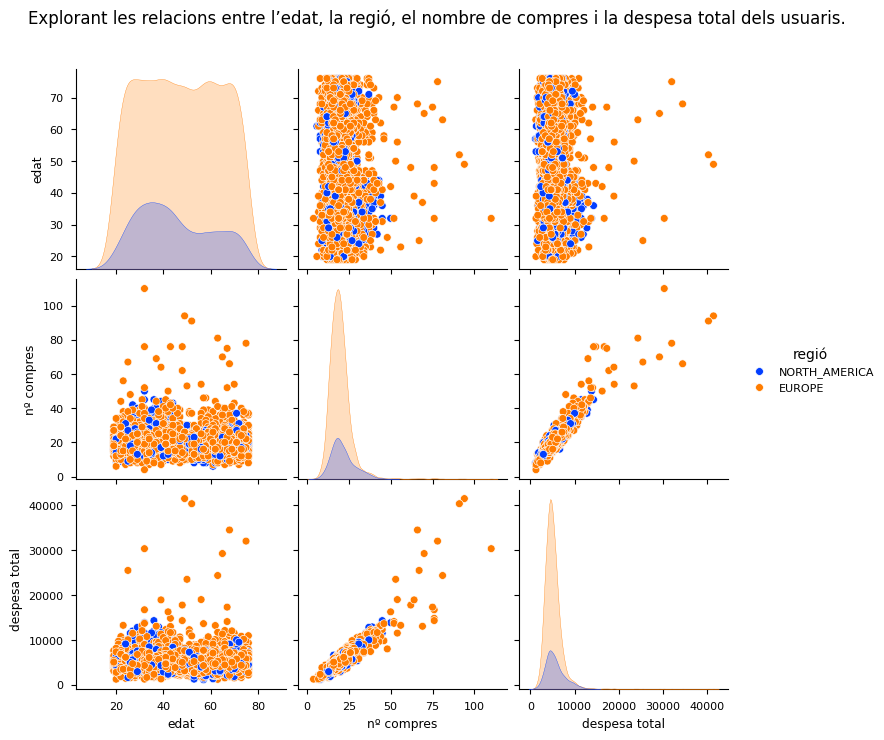

In [15]:
transaction_metrics = df['transaction'].groupby( 'user_id' ).agg(
    total_purchases=( 'id', 'size' ),
    total_amount=( 'amount', 'sum' )
).reset_index()

df_ut = pd.merge(
    df['user'][['id', 'age', 'region']], 
    transaction_metrics, 
    left_on='id', 
    right_on='user_id', 
    how='inner'
).drop( columns=['user_id'] )

df_ut           = df_ut[['age', 'total_purchases', 'total_amount', 'region']].dropna()
df_ut.columns   = ['edat', 'nº compres', 'despesa total','regió']

pair = sns.pairplot(
    df_ut,
    hue='regió', 
    palette='bright'
)

pair.figure.suptitle( "Explorant les relacions entre l’edat, la regió, el nombre de compres i la despesa total dels usuaris." )
pair.figure.subplots_adjust( top=0.90 )

plt.show()
plt.close()

Es pot apreciar un volum d’usuaris més gran a la regió europea que a l’americana, amb una franja d’edat més estable a Europa. A Amèrica, la proporció d’usuaris entre 30 i 40 anys és més elevada. A nivell de compres, a més usuaris, més compres i més despesa; ambdues regions presenten un comportament equivalent.
Com es pot intuir, hi ha una relació positiva entre el nombre de compres i la despesa total dels usuaris. Però no s’observa cap relació entre l’edat i el nombre de compres, ni tampoc entre l’edat i la despesa dels usuaris.
S’aprecia clarament una concentració en les franges de fins a 50 compres i al voltant dels 10.000 \$ de despesa total, amb alguns casos puntuals per sobre d’aquests valors.



# Nivell 2

## 1.
Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

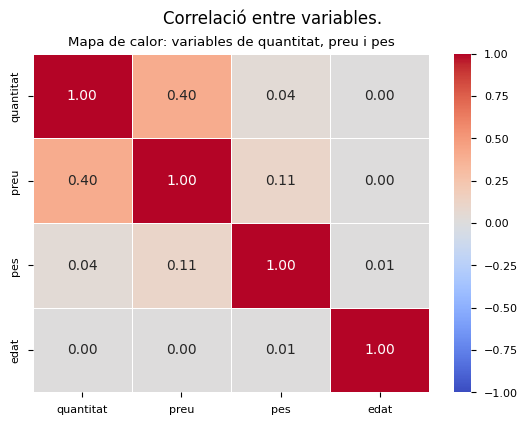

In [16]:
df_corr = pd.merge( df['transaction_product'][['transaction_id', 'product_id']],df['transaction'][['id','amount','user_id','declined']], left_on='transaction_id', right_on='id', how='inner'
                   ).merge( df['user'][['id','age']], left_on='user_id', right_on='id', how='inner'       
                   ).merge( df['product'][['id', 'price','weight']], left_on='product_id', right_on='id', how='inner' ).drop( columns= ['id','id_x','id_y'] )


plt.suptitle( "Correlació entre variables." )
plt.title( "Mapa de calor: variables de quantitat, preu i pes" )

num_df_corr = df_corr[['amount','price','weight', 'age']]
num_df_corr.columns = ['quantitat', 'preu', 'pes','edat']

sns.heatmap( num_df_corr.corr( method='pearson'), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmax=1, vmin=-1 );

plt.show()
plt.close()


De les variables escollides [ quantitat (per transacció), preu del producte, pes del producte i edat ] es pot apreciar una correlació moderada entre la quantitat i el preu, com a única rellevant a destacar. En canvi, entre el preu i el pes, així com entre la quantitat i el pes, la correlació és molt feble com per considerar-la significativa. La correlació entre l’edat i la resta de variables és nul·la, cosa que indica que l’edat no és un factor determinant en el comportament de l’usuari.

## 2.
Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

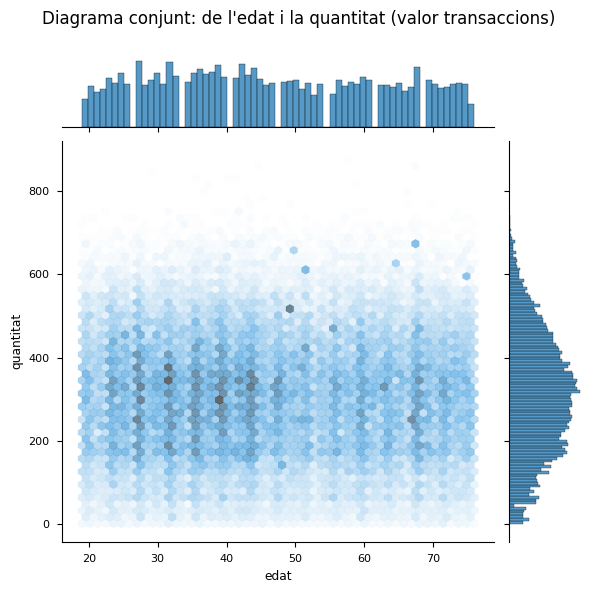

In [17]:
join = sns.jointplot( data=num_df_corr, x='edat', y='quantitat', alpha=0.6, kind='hex' );
join.figure.suptitle( "Diagrama conjunt: de l'edat i la quantitat (valor transaccions)" )
join.figure.subplots_adjust( top=0.90 )


En relació amb la variable edat, s’observa que hi ha petits buits en l’espectre d’usuaris, però el volum per edat és bastant homogeni. La major part de les transaccions se situen al voltant dels 300 \$, i presenten una distribució aproximadament normal. En el scatter plot, de tipus hex, es poden apreciar petits valors màxims en la zona dels 30–40 anys i al voltant dels 350 \$, amb tons més foscos.